**FinSights AI - Sentiment-Augmented Stock Market Forecasting**
---
---


---



# Module 1A - Data Collection & Exploration

/tmp/ipython-input-3374462278.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start="2022-01-01", end="2025-01-01")
[*********************100%***********************]  1 of 1 completed


/nDataset Shape: (753, 5)
/nColumns: MultiIndex([( 'Close', 'INFY'),
            (  'High', 'INFY'),
            (   'Low', 'INFY'),
            (  'Open', 'INFY'),
            ('Volume', 'INFY')],
           names=['Price', 'Ticker'])


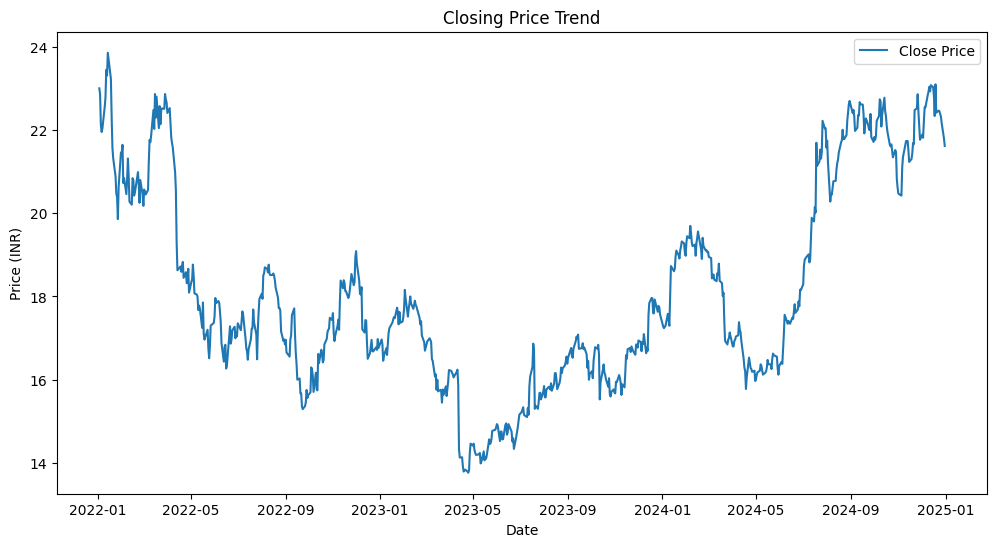

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

#Step 1: Download Stock Data
ticker = "INFY"
df = yf.download(ticker, start="2022-01-01", end="2025-01-01")
df.head()

print("/nDataset Shape:", df.shape)
print("/nColumns:", df.columns)

#Step 2: Visualize closing price trend
plt.figure(figsize=(12,6))
plt.plot(df['Close'], label='Close Price')
plt.title('Closing Price Trend')
plt.xlabel('Date')
plt.ylabel('Price (INR)')
plt.legend()
plt.show()

# Module 1B - Collect News Data via NewsAPI

In [ ]:
!pip install newsapi-python textblob

In [ ]:
from newsapi import NewsApiClient
from textblob import TextBlob
import pandas as pd
import datetime

#Intialize API Key
newsapi = NewsApiClient(api_key='6c3873698b584ee89dab96e14bcfaf7a')

#Fetch News Headlines
all_articles = newsapi.get_everything(q='Infosys', language='en', sort_by='publishedAt',
                                      from_param=(datetime.date.today() - datetime.timedelta(days=30)).isoformat(),
                                      to=(datetime.date.today()).isoformat(),
                                      page_size=50)

#Convert to DataFrame
news_data=pd.DataFrame(all_articles['articles'])
print("Sample News Articles")
print(news_data[['publishedAt', 'title', 'description']].head())

Sample News Articles
            publishedAt                                              title  \
0  2025-09-09T12:27:43Z  Sensex, Nifty rise on IT rally; Infosys, Wipro...   
1  2025-09-09T12:25:17Z  93% cryptocurrency investors want regulation, ...   
2  2025-09-09T11:14:49Z    Nifty, Sensex End Higher As Infosys Leads Gains   
3  2025-09-09T10:32:23Z  Market Wrap: Sensex gains 314 points, Nifty ab...   
4  2025-09-09T09:24:09Z  Buy Inox Wind Ltd., target price Rs 210.0 : Mo...   

                                         description  
0  Equity indices rise on IT stocks, global cues;...  
1  India tops global crypto adoption for the thir...  
2  The benchmark equity indices ended higher on T...  
3  Indian equities closed higher on Tuesday, fuel...  
4  Buy Inox Wind Ltd. at a price target of Rs 210...  


In [ ]:
#Sentiment Analysis
def get_sentiment(text):
  if text:
    return TextBlob(text).sentiment.polarity
  else:
    return 0
news_data['Sentiment']= news_data['title'].apply(get_sentiment)
print("\nNews Sentiment Scores: :")
print(news_data[['title', 'Sentiment']].head())


News Sentiment Scores: :
                                               title  Sentiment
0  Sensex, Nifty rise on IT rally; Infosys, Wipro...       0.50
1  93% cryptocurrency investors want regulation, ...      -0.25
2    Nifty, Sensex End Higher As Infosys Leads Gains       0.25
3  Market Wrap: Sensex gains 314 points, Nifty ab...       0.00
4  Buy Inox Wind Ltd., target price Rs 210.0 : Mo...       0.00


In [ ]:
#Convert timestamp
news_data['date'] = pd.to_datetime(news_data['publishedAt']).dt.date

daily_sentiment = news_data.groupby('date')['Sentiment'].mean().reset_index()
daily_sentiment.rename(columns={'date': 'Date', 'sentiment': 'avg_sentiment'}, inplace=True)

print("\nDaily Sentiment Scores:")
print(daily_sentiment.head())


Daily Sentiment Scores:
         Date  Sentiment
0  2025-09-08   0.021875
1  2025-09-09   0.084520


#Module  - Debugging And Error Handling With NewsAPI

In [ ]:
from newsapi import NewsApiClient
import datetime
import pandas as pd

API_Key = "6c3873698b584ee89dab96e14bcfaf7a"
newsapi = NewsApiClient(api_key=API_Key)

try:
  all_articles = newsapi.get_everything(
      q="Infosys", language="en", sort_by="publishedAt", from_param=(datetime.date.today)-datetime.timedelta(days=30).isoformat(),
      to=(datetime.date.today()).isoformat(), page_size=50
  )

  #Check if we got the data
  if 'articles' in all_articles and len(all_articles['articles'])>0:
    news_data = pd.DataFrame(all_articles['articles'])
  print("News Articles fetched successfully.")
  print(news_data[['publishedAt', 'title', 'description']].head())

except Exception as e:
  print("Error fetching news articles:", e)

Error fetching news articles: 'datetime.timedelta' object has no attribute 'isoformat'


In [ ]:
#Handling Missing Data
news_data['title']=news_data['title'].fillna('No Title')
news_data['description']=news_data['description'].fillna('No Description')

In [ ]:
#Handle API Rate Limits
#Free plan of NewsAPI → ~100 requests/day.
#If you hit limit, you’ll see error: "requests.exceptions.HTTPError: 429 Too Many Requests

import time

for page in range(1, 6): #fetch multiple pages
  try:
    data = newsapi.get_everything(q="Infosys", language="en", sort_by="publishedAt", page=page)
    print(f"Page {page} fetched, articles:", len(data['articles']))
    time.sleep(2)  #Avoid hitting rate limit
  except Exception as e:
    print(f"Error fetching page {page}:", e)

Page 1 fetched, articles: 99
Page 2 fetched, articles: 99
Page 3 fetched, articles: 100
Page 4 fetched, articles: 100
Page 5 fetched, articles: 100


# Module 2 - Preprocessing & Merging Stock + Sentiment

Stock Data:
        Date  Close_Price
0 2022-01-03    22.998482
1 2022-01-04    22.861908
2 2022-01-05    22.124428
3 2022-01-06    21.951437
4 2022-01-07    22.033382

Sentiment Data:
        Date  Sentiment
0 2025-09-08   0.021875
1 2025-09-09   0.084520

Merged Data:
        Date  Close_Price  Sentiment
0 2022-01-03    22.998482        NaN
1 2022-01-04    22.861908        NaN
2 2022-01-05    22.124428        NaN
3 2022-01-06    21.951437        NaN
4 2022-01-07    22.033382        NaN


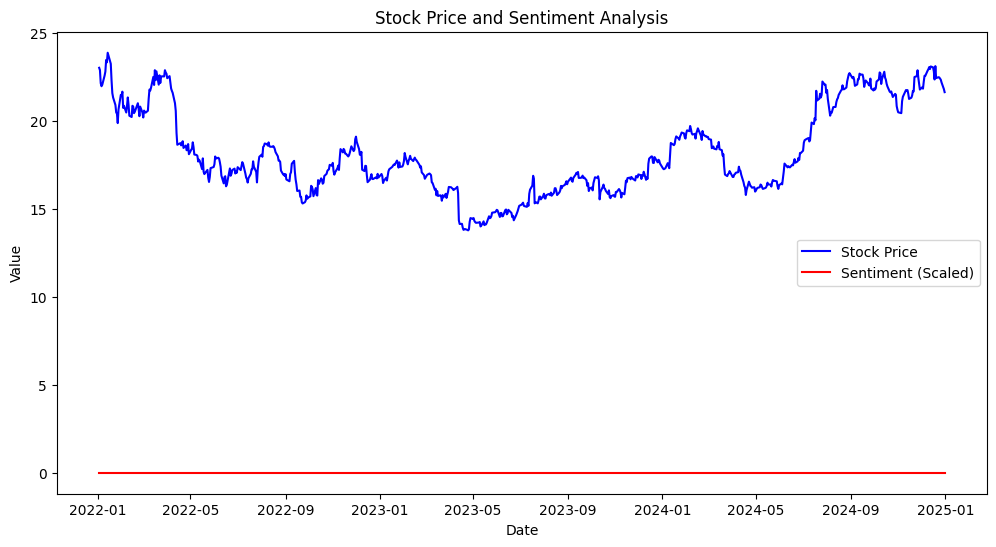

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# First: we will clean the data
stock_df = df.copy()
stock_df = stock_df[['Close']] # Select 'Close' column and keep as DataFrame
stock_df.columns = ['Close_Price'] # Rename the column to 'Close_Price'
stock_df.reset_index(inplace=True) # Reset the index to make 'Date' a column


print("Stock Data:")
print(stock_df.head())

#Second: we will clean the sentiment dataset
sentiment_df = daily_sentiment.copy()
sentiment_df['Date'] = pd.to_datetime(sentiment_df['Date'])

print ("\nSentiment Data:")
print(sentiment_df.head())

#Third: Merge stock + sentiment on Data
merged_df = pd.merge(stock_df, sentiment_df, on='Date', how='left')

print("\nMerged Data:")
print(merged_df.head())

#Fill missing sentiment with 0 -> as if we dont do this, the graph will not show the sentiment plot and the merged data will have NaN values.
merged_df['Sentiment'] = merged_df['Sentiment'].fillna(0)

# Scale sentiment for plotting (multiply so it’s visible against price)
scale_factor = merged_df['Close_Price'].mean() * 0.1   # ~10% of price range
merged_df['Sentiment_Scaled'] = merged_df['Sentiment'] * scale_factor

#Fourth: Feature Engineering - Price Change %
merged_df['Price_Change_pct'] = merged_df['Close_Price'].pct_change()


#Fifth: We will have a Quick Visualization for the data
plt.figure(figsize=(12,6))
plt.plot(merged_df['Date'], merged_df['Close_Price'], label="Stock Price", color="blue")
plt.plot(merged_df['Date'], merged_df['Sentiment_Scaled'], label="Sentiment (Scaled)", color="red")
plt.title("Stock Price and Sentiment Analysis")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.show()

# Module 3A - Stock Forecasting With Prophet

In [ ]:
!pip install prophet
from prophet import Prophet
import matplotlib.pyplot as plt

In [ ]:
#Prepare Data for Prophet
prophet_df = merged_df[['Date','Close_Price']].rename(columns={'Date':'ds','Close_Price':'y'})
print(prophet_df.head())

          ds          y
0 2022-01-03  22.998482
1 2022-01-04  22.861908
2 2022-01-05  22.124428
3 2022-01-06  21.951437
4 2022-01-07  22.033382


In [ ]:
#Train Prophet Model
model = Prophet(daily_seasonality=True)
model.fit(prophet_df)

DEBUG:cmdstanpy:input tempfile: /tmp/tmp6f094dad/9_8pf2ar.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp6f094dad/ej7_syzw.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=17540', 'data', 'file=/tmp/tmp6f094dad/9_8pf2ar.json', 'init=/tmp/tmp6f094dad/ej7_syzw.json', 'output', 'file=/tmp/tmp6f094dad/prophet_modelmrp00xuj/prophet_model-20250910131413.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
13:14:13 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
13:14:13 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


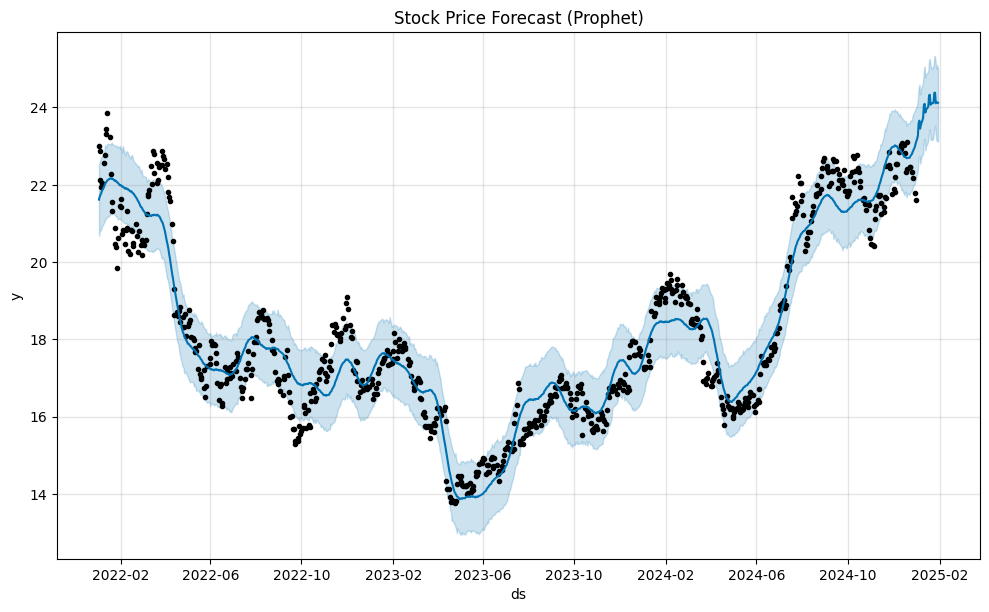

In [ ]:
#MAKE PREDICTIONS

#Predict next 30 days
future = model.make_future_dataframe(periods=30)
forecast = model.predict(future)

#Now we will plot the forecast
fig1 = model.plot(forecast)
plt.title("Stock Price Forecast (Prophet)")
plt.show()

# Module 3B - Classification With RandomForest

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

In [ ]:
#STEP 1: First we need to create a target value (UP = 1, DOWN = 2)
merged_df['Target'] = (merged_df['Price_Change_pct']>0).astype(int)

# Add the new features before defining X and y
merged_df['Sentiment_Smoothed'] = merged_df['Sentiment'].rolling(window=5, min_periods=1).mean()
merged_df['SMA_5'] = merged_df['Close_Price'].rolling(window=5).mean()
merged_df['SMA_10'] = merged_df['Close_Price'].rolling(window=10).mean()
merged_df['Volatility'] = merged_df['Close_Price'].rolling(window=10).std()


#STEP 2: Now we need to determine the functions like features (X) and target(y)
features = ['Price_Change_pct', 'Sentiment_Smoothed', 'SMA_5', 'SMA_10', 'Volatility'] # Updated features
X = merged_df[features].fillna(0)
y = merged_df['Target']

In [ ]:
#STEP 3: Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)

#STEP 4: Now our import step will be to train the RandomForest Model
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
#STEP 5: Prediction
y_pred = clf.predict(X_test)

#STEP 6: Evaluate Model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")
print(classification_report(y_test, y_pred))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        72
           1       1.00      1.00      1.00        79

    accuracy                           1.00       151
   macro avg       1.00      1.00      1.00       151
weighted avg       1.00      1.00      1.00       151



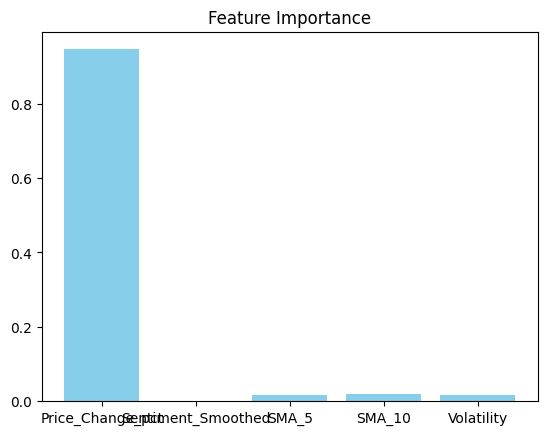

In [ ]:
# Get the actual feature names used in training
actual_features = X.columns

# Feature importance values
importance = clf.feature_importances_

# Plot
plt.bar(actual_features, importance, color="SkyBlue")
plt.title("Feature Importance")
plt.show()


In [ ]:
print(merged_df['Sentiment'].describe())
print(merged_df['Sentiment'].value_counts())

count    753.0
mean       0.0
std        0.0
min        0.0
25%        0.0
50%        0.0
75%        0.0
max        0.0
Name: Sentiment, dtype: float64
Sentiment
0.0    753
Name: count, dtype: int64


Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        72
           1       1.00      1.00      1.00        79

    accuracy                           1.00       151
   macro avg       1.00      1.00      1.00       151
weighted avg       1.00      1.00      1.00       151



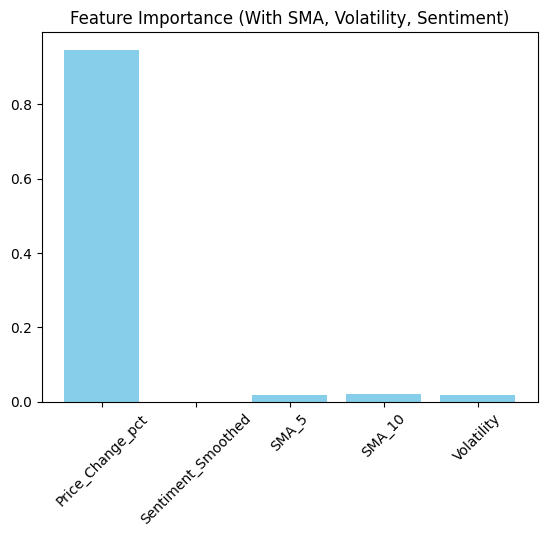

In [ ]:
#RandomForest With Advanced features

#Step-1
#5-day and 10-day Simple Moving averages (trend indicators)
merged_df['SMA_5'] = merged_df['Close_Price'].rolling(window=5).mean()
merged_df['SMA_10'] = merged_df['Close_Price'].rolling(window=10).mean()

#Volatility = Standard Deviation over 10 days
merged_df['Volatility'] = merged_df['Close_Price'].rolling(window=10).std()

#Smoothed Sentiment (7-day rolling average)
merged_df['Sentiment_Smoothed'] = merged_df['Sentiment'].rolling(window=5, min_periods=1).mean()

#Step-2 : Define features and target
features = ['Price_Change_pct', 'Sentiment_Smoothed', 'SMA_5', 'SMA_10', 'Volatility']
X = merged_df[features].fillna(0)
y = merged_df['Target']

#Step-3 : train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)

#Step-4 : Train RandomForest
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

#Step-5 : Prediction and Evaluation
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")
print(classification_report(y_test, y_pred))

#Step-6 : Feature Importance Plot
importance = clf.feature_importances_
plt.bar(X.columns, importance, color="skyblue")
plt.title("Feature Importance (With SMA, Volatility, Sentiment)")
plt.xticks(rotation=45)
plt.show()

In [ ]:
!pip install ta

  Preparing metadata (setup.py) ... done
  Created wheel for ta: filename=ta-0.11.0-py3-none-any.whl size=29412 sha256=d77865fe1c671c432d3bfb79bb526ac330e854be7cdefe381e6dddb8065f0644
  Stored in directory: /root/.cache/pip/wheels/5c/a1/5f/c6b85a7d9452057be4ce68a8e45d77ba34234a6d46581777c6
Successfully built ta


In [ ]:
#Adding RSI & MACD to Features

#Step-1 : Import & Compute Indicators
import ta
#RSI (Relative Strength Index) - momentum indicator (usually 14 days)
merged_df['RSI'] = ta.momentum.RSIIndicator(close=merged_df['Close_Price'], window=14).rsi()

#MACD (Moving Average Convergence Divergence) - trend indicator
macd = ta.trend.MACD(close=merged_df['Close_Price'],
                      window_slow=26,
                      window_fast=12,
                      window_sign=9)
merged_df['MACD'] = macd.macd()
merged_df['MACD_Signal'] = macd.macd_signal()

In [ ]:
#Step-2 : Update Features
features = [
    'Price_Change_pct',
    'Sentiment_Smoothed',
    'SMA_5',
    'SMA_10',
    'Volatility',
    'RSI',
    'MACD',
    'MACD_Signal'
]

X = merged_df[features].fillna(0)
y = merged_df['Target']

Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        72
           1       1.00      1.00      1.00        79

    accuracy                           1.00       151
   macro avg       1.00      1.00      1.00       151
weighted avg       1.00      1.00      1.00       151



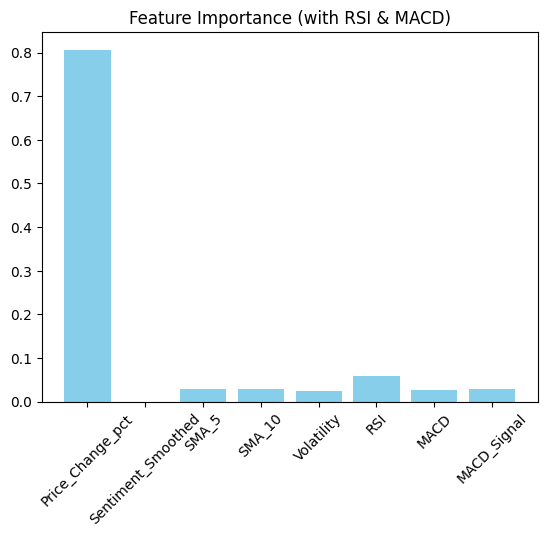

In [ ]:
#Step-3 : Train RandomForest Again
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=False
)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Feature importance plot
importance = clf.feature_importances_
plt.bar(X.columns, importance, color="skyblue")
plt.title("Feature Importance (with RSI & MACD)")
plt.xticks(rotation=45)
plt.show()

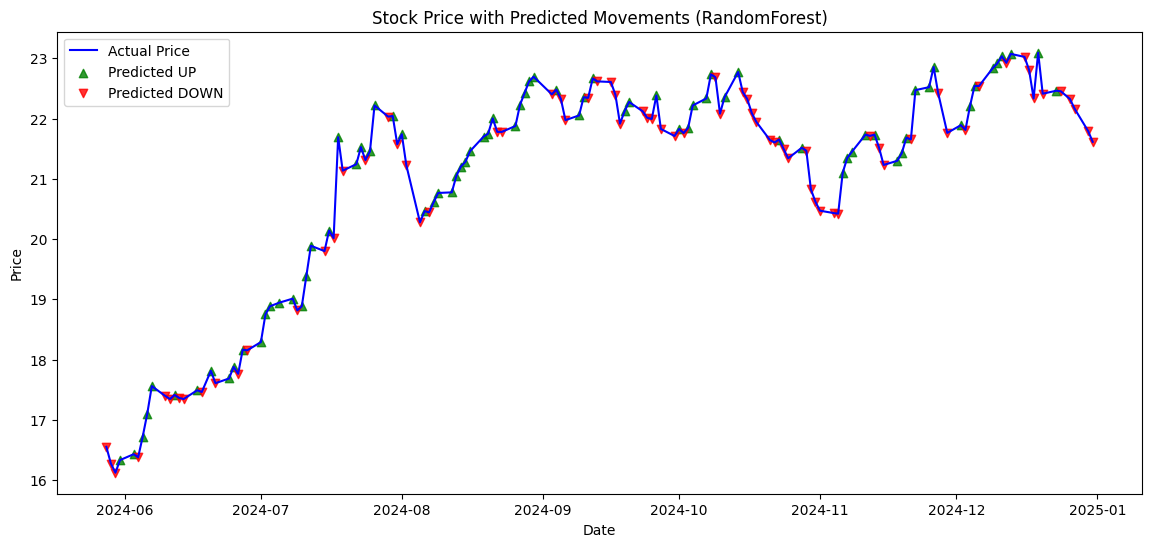

In [ ]:
#Plotting Actual vs Predicted UP/DOWN on Stock Chart

#Step-1 : Create a dataframe with predictions
results_df = merged_df.iloc[y_test.index].copy()
results_df['Predicted_Target'] = y_pred
results_df['Actual'] = y_test.values

#Step-2 : Plot stock price with predicted vs actual signals
plt.figure(figsize=(14, 6))
plt.plot(results_df['Date'], results_df['Close_Price'], label='Actual Price', color='blue')

#Mark predicted UP days
plt.scatter(results_df['Date'][results_df['Predicted_Target']==1],
            results_df['Close_Price'][results_df['Predicted_Target']==1],
            label="Predicted UP", marker="^", color="green", alpha=0.8)

# Mark predicted DOWN days
plt.scatter(results_df['Date'][results_df['Predicted_Target']==0],
            results_df['Close_Price'][results_df['Predicted_Target']==0],
            label="Predicted DOWN", marker="v", color="red", alpha=0.8)

plt.title("Stock Price with Predicted Movements (RandomForest)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

#Module 4 - Visualization & Dashboard

In [ ]:
#Step 1 : Install & import Plotly
!pip install Plotly
import plotly.graph_objects as go

In [ ]:
from prophet import Prophet
import plotly.graph_objects as go

# STEP 2 + 3: Prophet Forecast + Visualization

# Prepare data for Prophet
prophet_df = merged_df[['Date', 'Close_Price']].rename(
    columns={'Date': 'ds', 'Close_Price': 'y'}
)

# Initialize and fit the model
model = Prophet()
model.fit(prophet_df)

# Make future dataframe (e.g., 90 days ahead)
future = model.make_future_dataframe(periods=90)
forecast = model.predict(future)

# --- PLOTLY VISUALIZATION ---
fig2 = go.Figure()

# Forecast line
fig2.add_trace(go.Scatter(
    x=forecast['ds'], y=forecast['yhat'],
    mode='lines', name='Forecast',
    line=dict(color='green')
))

# Upper bound
fig2.add_trace(go.Scatter(
    x=forecast['ds'], y=forecast['yhat_upper'],
    mode='lines', name='Upper Bound',
    line=dict(dash='dot', color='gray')
))

# Lower bound
fig2.add_trace(go.Scatter(
    x=forecast['ds'], y=forecast['yhat_lower'],
    mode='lines', name='Lower Bound',
    line=dict(dash='dot', color='red')
))

# Layout
fig2.update_layout(
    title="Prophet Forecast (With Confidence Intervals)",
    xaxis_title="Date",
    yaxis_title="Predicted Price",
    template="plotly_dark"
)

fig2.show()

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp6f094dad/i_iw3l24.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp6f094dad/02dhocfy.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=28820', 'data', 'file=/tmp/tmp6f094dad/i_iw3l24.json', 'init=/tmp/tmp6f094dad/02dhocfy.json', 'output', 'file=/tmp/tmp6f094dad/prophet_modelq28jfig9/prophet_model-20250910131443.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
13:14:43 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
13:14:43 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


In [ ]:
#Step 4 : RandomForest With Feature Importance
fig3 = go.Figure([go.Bar(
    x=X.columns,
    y=clf.feature_importances_,
    marker_color="skyblue"
)])

# Bar chart for feature importance
fig3.update_layout(
    title="RandomForest Feature Importance",
    xaxis_title="Features",
    yaxis_title="Importance",
    template="plotly_dark"
)

fig3.show()

In [ ]:
#Step 5 : Predicted vs Actual Movements
fig4 = go.Figure()

# Stock price line
fig4.add_trace(go.Scatter(
    x=results_df['Date'],
    y=results_df['Close_Price'],
    mode='lines',
    name='Stock Price',
    line=dict(color='blue')
))

# Predicted UP (▲)
fig4.add_trace(go.Scatter(
    x=results_df['Date'][results_df['Predicted_Target']==1],
    y=results_df['Close_Price'][results_df['Predicted_Target']==1],
    mode='markers',
    name='Predicted UP',
    marker=dict(symbol='triangle-up', color='green', size=10)
))

# Predicted DOWN (▼)
fig4.add_trace(go.Scatter(
    x=results_df['Date'][results_df['Predicted_Target']==0],
    y=results_df['Close_Price'][results_df['Predicted_Target']==0],
    mode='markers',
    name='Predicted DOWN',
    marker=dict(symbol='triangle-down', color='red', size=10)
))

fig4.update_layout(
    title="Predicted UP/DOWN Movements",
    xaxis_title="Date",
    yaxis_title="Price",
    template="plotly_dark"
)

fig4.show()

#Module 5 - Model Evaluation

RandomForest Evaluation Metrics:
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0


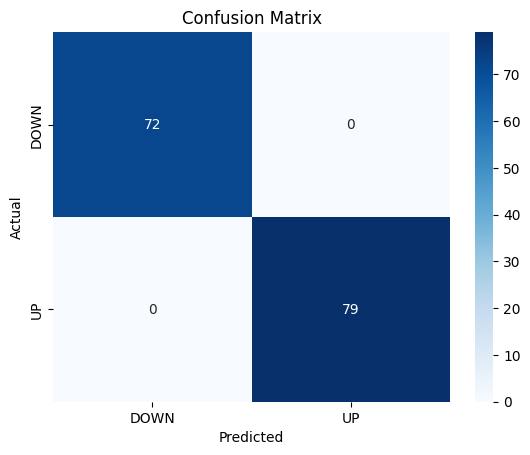

DEBUG:cmdstanpy:input tempfile: /tmp/tmp6f094dad/3qtefvws.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp6f094dad/40gzw5xt.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=99681', 'data', 'file=/tmp/tmp6f094dad/3qtefvws.json', 'init=/tmp/tmp6f094dad/40gzw5xt.json', 'output', 'file=/tmp/tmp6f094dad/prophet_model7tw0_q9j/prophet_model-20250910131450.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
13:14:50 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
13:14:50 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing



Prophet Evaluation:
MAE: 3.104897433274709
RMSE: 3.342442639695873
R² Score: -2.2468135353369223


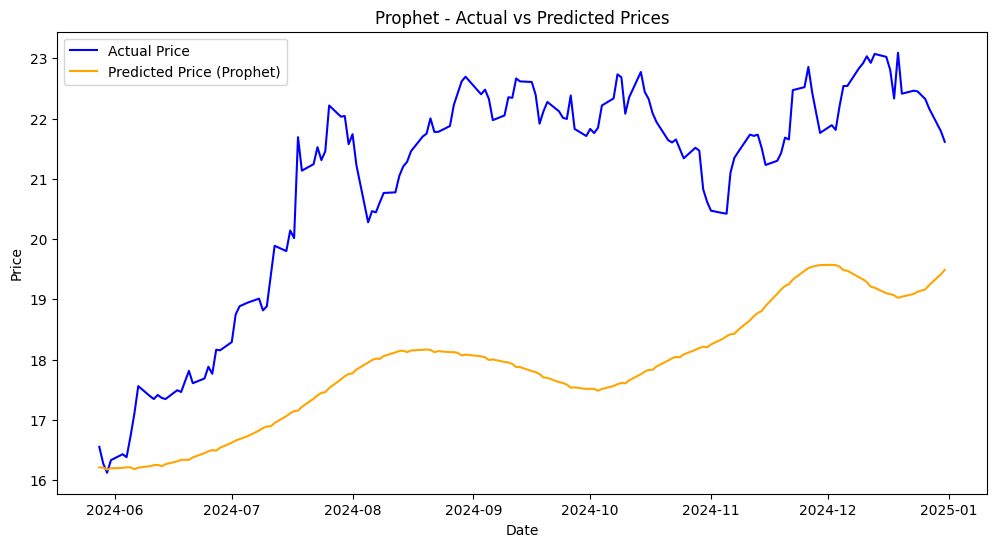

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#Train Test Split For RANDOMFOREST

#Features And Target for RF
X = merged_df[['Price_Change_pct', 'Sentiment_Smoothed', 'SMA_5', 'SMA_10', 'Volatility']]
Y = (merged_df['Price_Change_pct']>0).astype(int)  # 1 = UP, 0 = DOWN

#Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

#Train RF Model
clf.fit(X_train, y_train)

#Prediction
y_pred = clf.predict(X_test)

# RF Evaluation Metrics
print("RandomForest Evaluation Metrics:")
print(f"Accuracy:", accuracy_score(y_test, y_pred))
print(f"Precision:", precision_score(y_test, y_pred))
print(f"Recall:", recall_score(y_test, y_pred))
print(f"F1 Score:", f1_score(y_test, y_pred))

#Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["DOWN", "UP"], yticklabels=["DOWN", "UP"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

#PROPHET EVALUATION
from prophet import Prophet

#prepare data for prophet
prophet_df = merged_df[['Date', 'Close_Price']].rename(columns={'Date': 'ds', 'Close_Price': 'y'})

#Train test split for Prophet Model
train_size = int(len(prophet_df) * 0.8)
train_data = prophet_df.iloc[:train_size]
test_data = prophet_df.iloc[train_size:].copy() # Create a copy to avoid SettingWithCopyWarning

#Train Prophet
m = Prophet(daily_seasonality=True)
m.fit(train_data)

#Forecast for the test period
future = pd.DataFrame({'ds': test_data['ds']}) # Create future dataframe with dates from test_data
forecast = m.predict(future)


#Merge actual and predicted values
evaluation_df = pd.merge(test_data, forecast[['ds', 'yhat']], on='ds', how='left')
evaluation_df.set_index('ds', inplace=True)


# Metrics
mae = mean_absolute_error(evaluation_df['y'], evaluation_df['yhat'])
rmse = np.sqrt(mean_squared_error(evaluation_df['y'], evaluation_df['yhat']))
r2 = r2_score(evaluation_df['y'], evaluation_df['yhat'])

print("\nProphet Evaluation:")
print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

# Plot Actual vs Predicted
plt.figure(figsize=(12,6))
plt.plot(evaluation_df.index, evaluation_df['y'], label="Actual Price", color="blue")
plt.plot(evaluation_df.index, evaluation_df['yhat'], label="Predicted Price (Prophet)", color="orange")
plt.title("Prophet - Actual vs Predicted Prices")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

#Module 6A - Flask API

In [ ]:
#Step 1 - Setup
!pip install flask

In [ ]:
import pickle
with open("random_forest_model.pkl", "wb") as f:
  pickle.dump(clf, f)

In [ ]:
# Save the stock data to a CSV file
df.reset_index().to_csv('stock_data.csv', index=False)

In [ ]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 32.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 73.7 MB/s eta 0:00:00


In [ ]:
import streamlit as st
import pandas as pd
from prophet import Prophet
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# -------------------------------
# STREAMLIT DASHBOARD START
# -------------------------------
st.title("📈 Finsights AI - Stock Prediction Dashboard")

# Upload CSV
uploaded_file = st.file_uploader("Upload your stock data CSV", type=["csv"])
if uploaded_file is not None:
    df = pd.read_csv(uploaded_file)

    # Show data preview
    st.subheader("Raw Data Preview")
    st.write(df.head())

    # -------------------------------
    # STEP 1: Prepare data for Prophet
    # -------------------------------
    st.subheader("Data Preprocessing")

    # Debugging: show columns
    st.write("Columns in CSV:", df.columns.tolist())

    # Rename columns for Prophet compatibility
    if "Close_Price" in df.columns:
        df = df.rename(columns={"Date": "ds", "Close_Price": "y"})
    elif "Close" in df.columns:
        df = df.rename(columns={"Date": "ds", "Close": "y"})
    elif "Adj Close" in df.columns:
        df = df.rename(columns={"Date": "ds", "Adj Close": "y"})
    else:
        st.error("No valid closing price column found! Must contain 'Close_Price', 'Close', or 'Adj Close'.")
        st.stop()

    # Keep only Prophet-required columns
    df = df[["ds", "y"]]

    # Convert to correct datatypes
    df["ds"] = pd.to_datetime(df["ds"], errors="coerce")
    df["y"] = pd.to_numeric(df["y"], errors="coerce")
    df = df.dropna()

    st.write("✅ Data formatted for Prophet:", df.head())

    # -------------------------------
    # STEP 2: Prophet Forecasting
    # -------------------------------
    st.subheader("📊 Prophet Forecasting")

    prophet_model = Prophet(daily_seasonality=True)
    prophet_model.fit(df)

    future = prophet_model.make_future_dataframe(periods=30)  # Predict next 30 days
    forecast = prophet_model.predict(future)

    # Show forecast chart
    st.write("### Forecast Plot")
    fig1 = prophet_model.plot(forecast)
    st.pyplot(fig1)

    # Show forecast components (trend, seasonality)
    st.write("### Forecast Components")
    fig2 = prophet_model.plot_components(forecast)
    st.pyplot(fig2)

    # -------------------------------
    # STEP 3: RandomForest Classifier
    # -------------------------------
    st.subheader("🤖 RandomForest Classification (Price UP/DOWN)")

    # Create simple features
    df["Return"] = df["y"].pct_change()
    df["Target"] = (df["Return"] > 0).astype(int)  # 1 if price went up, else 0
    df = df.dropna()

    X = df[["Return"]]
    y = df["Target"]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    st.write("### RandomForest Accuracy:", acc)

    # Show predictions
    results = pd.DataFrame({"Date": df["ds"].iloc[-len(y_test):], "Actual": y_test, "Predicted": y_pred})
    st.write("Predictions vs Actuals", results)

2025-09-10 15:02:30.817 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-09-10 15:02:31.230 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2025-09-10 15:02:31.231 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-09-10 15:02:31.232 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-09-10 15:02:31.233 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-09-10 15:02:31.234 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-09-10 15:02:31.235 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-09-10 15:02:31.236 Thread 'MainThread': mi

In [ ]:
# running in colab instead of an external editor like anaconda or vscode
!pip install streamlit pyngrok

In [ ]:
%%writefile app.py
print("Hello from app.py!")


Writing app.py


In [ ]:
!ls

app.py	random_forest_model.pkl  sample_data  stock_data.csv


In [ ]:
!pip install streamlit pyngrok -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 64.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 99.8 MB/s eta 0:00:00


In [ ]:
from pyngrok import ngrok
ngrok.set_auth_token("32VsRO23cYKdfkZFBSaLYNWdHCE_48iAZf3Bpsp9PPS876R53")

In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import yfinance as yf
from prophet import Prophet
import plotly.express as px
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# ----------------------------
# Streamlit App
# ----------------------------
st.set_page_config(page_title="Finsights AI", layout="wide")
st.title("📊 Finsights AI – Stock Market Trend Analysis")

# Sidebar
st.sidebar.header("User Input")
ticker = st.sidebar.text_input("Enter Stock Ticker (e.g., INFY, AAPL, TSLA)", "INFY")
period = st.sidebar.selectbox("Select Period", ["6mo", "1y", "2y", "5y"], index=1)
forecast_days = st.sidebar.slider("Forecast Days", min_value=7, max_value=90, value=30, step=7)
mode = st.sidebar.radio("Choose Analysis", ["📈 Prophet Forecasting", "🌲 RandomForest Classification"])

# ----------------------------
# Fetch Data
# ----------------------------
st.write(f"Fetching data for **{ticker}**...")
data = yf.download(ticker, period=period)

if data.empty:
    st.error("No data found for this ticker.")
    st.stop()

df = data.reset_index()

# Debugging: show df before using Prophet/ML
st.write("🔎 Raw Data Sample:", df.head())
st.write("Available Columns:", df.columns.tolist())

# ----------------------------
# Mode 1: Prophet Forecasting
# ----------------------------
if mode == "📈 Prophet Forecasting":
    st.subheader("📈 Prophet Forecasting")

    # Handle column naming safely
    if "Close" in df.columns:
        df_prophet = df.rename(columns={"Date": "ds", "Close": "y"})
    elif "Adj Close" in df.columns:
        df_prophet = df.rename(columns={"Date": "ds", "Adj Close": "y"})
    else:
        st.error("⚠️ No 'Close' or 'Adj Close' column found in Yahoo Finance data!")
        st.stop()

    # Keep only required columns
    df_prophet = df_prophet[["ds", "y"]].copy()

    # Convert datatypes
    df_prophet["ds"] = pd.to_datetime(df_prophet["ds"], errors="coerce")
    df_prophet["y"] = pd.to_numeric(df_prophet["y"], errors="coerce")

    # Drop bad rows
    df_prophet = df_prophet.dropna(subset=["ds", "y"]).reset_index(drop=True)

    # Debugging check
    st.write("✅ Cleaned Data for Prophet:", df_prophet.head())
    st.write("Cleaned dtypes:", df_prophet.dtypes)

    # Train Prophet
    prophet_model = Prophet(daily_seasonality=True)
    prophet_model.fit(df_prophet)

    # Forecast
    future = prophet_model.make_future_dataframe(periods=forecast_days, freq="D")
    forecast = prophet_model.predict(future)

    # Debugging
    st.write("🔎 Forecast Sample:", forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].head())
    st.write("Forecast shape:", forecast.shape)

    if forecast.shape[0] > 0:
        # Plot with confidence intervals
        fig = px.line(forecast, x="ds", y="yhat", title=f"{ticker} Stock Forecast (Next {forecast_days} Days)")
        fig.add_scatter(x=forecast["ds"], y=forecast["yhat_upper"], mode="lines",
                        name="Upper Bound", line=dict(dash="dot", color="gray"))
        fig.add_scatter(x=forecast["ds"], y=forecast["yhat_lower"], mode="lines",
                        name="Lower Bound", line=dict(dash="dot", color="red"))
        st.plotly_chart(fig, use_container_width=True)

        # Actual vs Predicted
        fig2, ax = plt.subplots(figsize=(10,5))
        ax.plot(df_prophet['ds'], df_prophet['y'], label="Actual", color="blue")
        ax.plot(forecast['ds'], forecast['yhat'], label="Predicted", color="orange")
        ax.fill_between(forecast['ds'], forecast['yhat_lower'], forecast['yhat_upper'],
                        alpha=0.2, color="gray")
        ax.legend()
        st.pyplot(fig2)
    else:
        st.error("⚠️ Forecast DataFrame is empty. Check input data.")

# ----------------------------
# Mode 2: RandomForest Classification
# ----------------------------
elif mode == "🌲 RandomForest Classification":
    st.subheader("🌲 RandomForest Classification – Predict UP/DOWN")

    # Make sure Close/Adj Close exists
    if "Close" not in df.columns and "Adj Close" in df.columns:
        df = df.rename(columns={"Adj Close": "Close"})

    # Create features
    df["Return"] = df["Close"].pct_change()
    df["SMA_5"] = df["Close"].rolling(window=5).mean()
    df["SMA_10"] = df["Close"].rolling(window=10).mean()
    df["Volatility"] = df["Return"].rolling(window=10).std()
    df["Target"] = (df["Return"] > 0).astype(int)

    df = df.dropna()

    features = ["Return", "SMA_5", "SMA_10", "Volatility"]
    X = df[features]
    y = df["Target"]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

    clf = RandomForestClassifier(n_estimators=100, random_state=42)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    st.write(f"✅ RandomForest Accuracy: **{acc:.2f}**")

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    fig3, ax = plt.subplots()
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["DOWN", "UP"], yticklabels=["DOWN", "UP"], ax=ax)
    ax.set_title("Confusion Matrix")
    st.pyplot(fig3)

    # Classification Report
    st.text("Classification Report:")
    st.text(classification_report(y_test, y_pred))

    # Feature Importance
    st.subheader("🔑 Feature Importance")
    importance = pd.DataFrame({"Feature": features, "Importance": clf.feature_importances_})
    fig4 = px.bar(importance, x="Feature", y="Importance", title="RandomForest Feature Importance")
    st.plotly_chart(fig4, use_container_width=True)


Overwriting app.py


In [ ]:
from pyngrok import ngrok, conf

# Kill all previous ngrok processes
!pkill -f ngrok

# Disconnect all tunnels (just in case)
ngrok.kill()


In [ ]:
!pip install streamlit yfinance prophet scikit-learn seaborn plotly pyngrok -q


In [ ]:
!streamlit run app.py &>/dev/null&

from pyngrok import ngrok
public_url = ngrok.connect(8501)
print("Your app is live at:", public_url)


Your app is live at: NgrokTunnel: "https://f2a486a16e62.ngrok-free.app" -> "http://localhost:8501"
